✅ Successfully imported DDRL modules.
Running 1000 simulations on cuda...

=== Statistical Report ===
Metric               | DDRL            | Finite Horizon GP
--------------------------------------------------------
Mean PnL             | 0.5551          | 0.5552
Std PnL              | 0.5466          | 0.5466
Max PnL              | 4.6608          | 4.6621
--------------------------------------------------------
Paired t-test: t=-16.86, p-value=2.4954e-56
>> Result: Statistically different, but gap is 0.03%.

Policy Fidelity:
R-squared (GP vs DDRL positions): 0.9998
MSE (Mean Squared Error): 0.018833


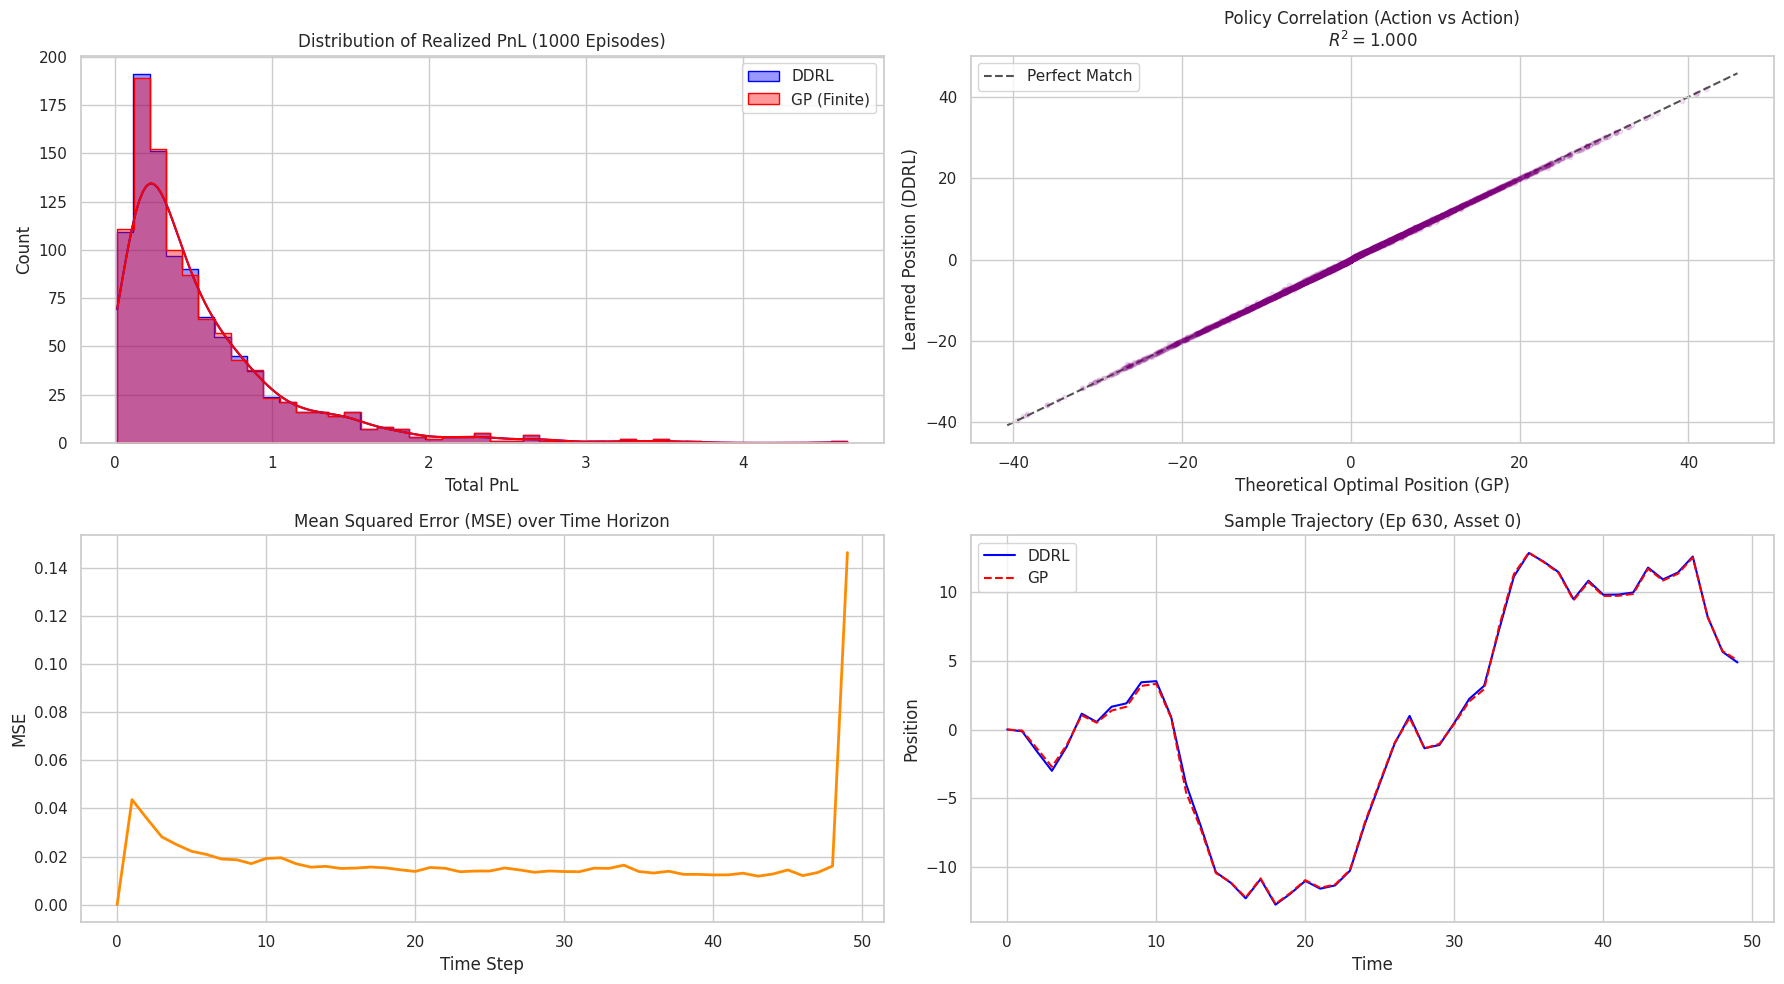

In [2]:
import torch
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import os

# --- 1. Notebook Path Setup ---
# Adjust this path so python can find the 'DDRL' folder.
# If your notebook is in 'DDRL/experiments/', going up 2 levels is correct.
# If imports fail, change this to the absolute path of your project root.
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Try importing to verify path
try:
    from DDRL.multi_asset.market_env import MarketEnv
    from DDRL.multi_asset.ddrl_agent import DDRLAgent
    print("✅ Successfully imported DDRL modules.")
except ImportError as e:
    print("❌ ImportError: Could not find DDRL modules.")
    print(f"Current sys.path includes: {sys.path}")
    print("Please manually append the parent directory of 'DDRL' to sys.path.")
    raise e

# ==========================================
# 2. Finite Horizon GP Solver (The Benchmark)
# ==========================================
def solve_gp_finite_horizon(params):
    A = np.array(params["matrices"]["alpha_weights"])
    B = np.array(params["matrices"]["return_weights"])
    Sigma = np.array(params["matrices"]["sigma"])
    Lambda = np.array(params["matrices"]["cost_lambda"]) 
    
    gamma = params["scalars"]["trader_risk"]
    horizon = params["scalars"]["horizon"]
    
    n_alpha = A.shape[0]
    n_asset = Sigma.shape[0]
    
    E_aa = np.zeros((n_alpha, n_alpha))
    E_aw = np.zeros((n_alpha, n_asset))
    E_ww = np.zeros((n_asset, n_asset))
    
    policies = [] # List of (K_alpha, K_w) for t=0..T-1
    
    # Backward induction
    for t in range(horizon - 1, -1, -1):
        M = np.linalg.inv(gamma * Sigma + Lambda + E_ww)
        K_alpha = M @ (B + E_aw.T @ A)
        K_w = M @ Lambda
        policies.insert(0, (K_alpha, K_w))
        
        # Update Value matrices
        E_ww_new = Lambda - Lambda @ M @ Lambda
        E_aw_new = (B.T + A.T @ E_aw) @ M @ Lambda
        E_aa_new = A.T @ E_aa @ A - (B + E_aw.T @ A).T @ M @ (B + E_aw.T @ A)
        
        E_ww, E_aw, E_aa = E_ww_new, E_aw_new, E_aa_new
        
    return policies

# ==========================================
# 3. Simulation Runner
# ==========================================
def run_comparison(num_episodes=1000):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Running {num_episodes} simulations on {device}...")

    # A. Load Parameters
    if not os.path.exists("debug_monomono.json"):
        raise FileNotFoundError("debug_monomono.json not found. Run the trainer export first.")
        
    with open("debug_monomono.json", "r") as f:
        params = json.load(f)

    # B. Initialize Environment & Agent
    env = MarketEnv(
        alpha_weights=torch.tensor(params["matrices"]["alpha_weights"], device=device),
        omega=torch.tensor(params["matrices"]["omega"], device=device),
        return_weights=torch.tensor(params["matrices"]["return_weights"], device=device),
        sigma=torch.tensor(params["matrices"]["sigma"], device=device),
        trader_risk=params["scalars"]["trader_risk"],
        dealer_risk=params["scalars"]["dealer_risk"],
        horizon=params["scalars"]["horizon"],
        device=device
    )
    
    # Load Trained Agent
    if not os.path.exists("Monoasset_monosignal.pt"):
        raise FileNotFoundError("Monoasset_monosignal.pt not found.")
        
    checkpoint = torch.load("Monoasset_monosignal.pt", map_location=device)
    agent = DDRLAgent(env, horizon=env.horizon, hidden_dim=300, device=device)
    agent.policy.load_state_dict(checkpoint["model_state_dict"])
    agent.policy.eval()

    # C. Solve GP
    gp_policies = solve_gp_finite_horizon(params)

    # D. Generate Data (Monte Carlo)
    U_batch = torch.randn(num_episodes, env.horizon, env.num_alphas, device=device)
    
    # --- 1. Run DDRL ---
    ddrl_positions = [] 
    ddrl_rewards = []   
    
    with torch.no_grad():
        state = env.reset(num_episodes)
        cum_reward = torch.zeros(num_episodes, device=device)
        
        for t in range(env.horizon):
            action = agent.policy(state)
            ddrl_positions.append(action.cpu().numpy())
            
            step_reward = env.reward(state, action)
            cum_reward += step_reward
            state = env.transition(state, action, U_batch[:, t, :])
            
        ddrl_rewards = cum_reward.cpu().numpy()
        ddrl_positions = np.stack(ddrl_positions, axis=1) # (N, T, Assets)

    # --- 2. Run GP ---
    A_np = np.array(params["matrices"]["alpha_weights"])
    Omega_np = np.array(params["matrices"]["omega"])
    L_np = np.linalg.cholesky(Omega_np)
    U_np = U_batch.cpu().numpy()
    
    gp_positions = np.zeros((num_episodes, env.horizon, env.num_assets))
    gp_rewards = np.zeros(num_episodes)
    
    current_alpha = np.zeros((num_episodes, env.num_alphas))
    current_w = np.zeros((num_episodes, env.num_assets))
    
    B = np.array(params["matrices"]["return_weights"])
    Sigma = np.array(params["matrices"]["sigma"])
    Lambda = np.array(params["matrices"]["cost_lambda"])
    gamma = params["scalars"]["trader_risk"]

    for t in range(env.horizon):
        K_alpha, K_w = gp_policies[t]
        
        # Policy: w_t = (alpha @ K_alpha.T) + (w_prev @ K_w.T) 
        target_w = current_alpha @ K_alpha.T + current_w @ K_w.T
        gp_positions[:, t, :] = target_w
        
        # Calculate Reward
        dw = target_w - current_w 
        exp_ret = current_alpha @ B.T
        signal = np.sum(target_w * exp_ret, axis=1)
        risk = 0.5 * gamma * np.sum(target_w * (target_w @ Sigma), axis=1)
        cost = 0.5 * np.sum(dw * (dw @ Lambda), axis=1) # Assuming 0.5 fix applied
        
        gp_rewards += (signal - risk - cost)
        
        # Transition
        current_alpha = current_alpha @ A_np.T + U_np[:, t, :] @ L_np.T
        current_w = target_w

    return ddrl_rewards, gp_rewards, ddrl_positions, gp_positions

# ==========================================
# 4. Statistical Analysis & Plotting
# ==========================================
def analyze_results(ddrl_r, gp_r, ddrl_pos, gp_pos):
    print("\n=== Statistical Report ===")
    
    # 1. PnL Stats
    mean_ddrl = np.mean(ddrl_r)
    mean_gp = np.mean(gp_r)
    t_stat, p_val = stats.ttest_rel(ddrl_r, gp_r)
    
    print(f"{'Metric':<20} | {'DDRL':<15} | {'Finite Horizon GP':<15}")
    print("-" * 56)
    print(f"{'Mean PnL':<20} | {mean_ddrl:.4f}          | {mean_gp:.4f}")
    print(f"{'Std PnL':<20} | {np.std(ddrl_r):.4f}          | {np.std(gp_r):.4f}")
    print(f"{'Max PnL':<20} | {np.max(ddrl_r):.4f}          | {np.max(gp_r):.4f}")
    print("-" * 56)
    print(f"Paired t-test: t={t_stat:.2f}, p-value={p_val:.4e}")
    
    if p_val > 0.05:
        print(">> Result: No statistically significant difference (Convergence achieved).")
    else:
        diff_pct = abs(mean_ddrl - mean_gp)/mean_gp * 100
        print(f">> Result: Statistically different, but gap is {diff_pct:.2f}%.")

    # 2. Policy Correlation
    flat_ddrl = ddrl_pos.flatten()
    flat_gp = gp_pos.flatten()
    
    slope, intercept, r_value, _, _ = stats.linregress(flat_gp, flat_ddrl)
    r_squared = r_value**2
    mse = np.mean((flat_ddrl - flat_gp)**2)
    
    print(f"\nPolicy Fidelity:")
    print(f"R-squared (GP vs DDRL positions): {r_squared:.4f}")
    print(f"MSE (Mean Squared Error): {mse:.6f}")

    # = PLOTTING =
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(18, 10))
    
    # Plot A: PnL Histogram
    ax1 = plt.subplot(2, 2, 1)
    sns.histplot(ddrl_r, color="blue", label="DDRL", kde=True, ax=ax1, alpha=0.4, element="step")
    sns.histplot(gp_r, color="red", label="GP (Finite)", kde=True, ax=ax1, alpha=0.4, element="step")
    ax1.set_title("Distribution of Realized PnL (1000 Episodes)")
    ax1.set_xlabel("Total PnL")
    ax1.legend()
    
    # Plot B: Policy Correlation Scatter
    ax2 = plt.subplot(2, 2, 2)
    sample_indices = np.random.choice(len(flat_ddrl), size=5000, replace=False)
    ax2.scatter(flat_gp[sample_indices], flat_ddrl[sample_indices], alpha=0.1, s=10, color="purple")
    lims = [min(flat_gp), max(flat_gp)]
    ax2.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label="Perfect Match")
    ax2.set_title(f"Policy Correlation (Action vs Action)\n$R^2 = {r_squared:.3f}$")
    ax2.set_xlabel("Theoretical Optimal Position (GP)")
    ax2.set_ylabel("Learned Position (DDRL)")
    ax2.legend()
    
    # Plot C: MSE over Time
    ax3 = plt.subplot(2, 2, 3)
    mse_t = np.mean((ddrl_pos - gp_pos)**2, axis=(0, 2))
    ax3.plot(mse_t, color="darkorange", linewidth=2)
    ax3.set_title("Mean Squared Error (MSE) over Time Horizon")
    ax3.set_xlabel("Time Step")
    ax3.set_ylabel("MSE")
    
    # Plot D: Sample Trajectory
    ax4 = plt.subplot(2, 2, 4)
    idx = np.random.randint(0, len(ddrl_r)) # Random episode
    asset_k = 0
    ax4.plot(ddrl_pos[idx, :, asset_k], label="DDRL", color="blue")
    ax4.plot(gp_pos[idx, :, asset_k], label="GP", color="red", linestyle="--")
    ax4.set_title(f"Sample Trajectory (Ep {idx}, Asset {asset_k})")
    ax4.set_xlabel("Time")
    ax4.set_ylabel("Position")
    ax4.legend()
    
    plt.tight_layout()
    plt.show()  # <--- Changed to show() for Notebooks

# ==========================================
# 5. Execution Cell
# ==========================================
# Run the analysis
try:
    ddrl_r, gp_r, ddrl_pos, gp_pos = run_comparison(num_episodes=1000)
    analyze_results(ddrl_r, gp_r, ddrl_pos, gp_pos)
except Exception as e:
    print(f"\nAn error occurred: {e}")